In [1]:
import pandas as pd
import numpy as np
import biom

from gemelli.rpca import feature_correlation_table, feature_covariance_table
from gemelli.rpca import joint_rpca, rpca
from skbio.stats.distance import permanova
from gemelli.preprocessing import matrix_rclr

#plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
def ordination_scatterplots(rpca_results, metadata, x="PC1", y="PC2",
                            hue=None, hue_order=None, palette="tab10", 
                            markers=None, style=None, style_order=None, 
                            point_size=100, subplots=(2,3), figsize=(25, 10)):

    if subplots is not None:
        fig, axn = plt.subplots(subplots[0], subplots[1], figsize=figsize)
        axn = axn.flatten()
    else:
        fig = plt.figure(figsize=figsize)
        axn = [plt.gca()]

    for ax, (tblid, (ord_, _, _)) in zip(axn, rpca_results.items()):
        #prepare dataframe
        ord_samples = ord_.samples.rename(columns={0:'PC1', 1:'PC2', 
                                                   2:'PC3', 3:'PC4'})
        ord_plt = pd.concat([ord_samples, metadata], axis=1, sort=True)
        
        #plotting
        sns.scatterplot(x=x, y=y, hue=hue, hue_order=hue_order, 
                        palette=palette, style=style, 
                        style_order=style_order, markers=markers, 
                        data=ord_plt, s=point_size, ax=ax)
        ax.set_xlabel(x + ' (%.2f%%)' % (ord_.proportion_explained[0] * 100), color='black', weight='bold', fontsize=22)
        ax.set_ylabel(y + ' (%.2f%%)' % (ord_.proportion_explained[1] * 100), color='black', weight='bold', fontsize=22)
        ax.set_title(tblid, color='black', weight='bold', fontsize=22)
        # fix backround
        ax.set_facecolor('white')
        ax.set_axisbelow(True)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['top'].set_visible(False)
        for child in ax.get_children():
            if isinstance(child, matplotlib.spines.Spine):
                child.set_color('grey')

        for tick in ax.get_yticklabels():
            tick.set_fontproperties('arial')
            tick.set_weight('bold')
            tick.set_color("black")
            tick.set_fontsize(14)
        for tick in ax.get_xticklabels():
            tick.set_fontproperties('arial')
            tick.set_weight('bold')
            tick.set_color("black")
            tick.set_fontsize(14)
        ax.legend_.remove()
        
    plt.tight_layout()

    if subplots is not None:
        legend = ax.legend(loc=2, bbox_to_anchor=(-1.1, 2.6),
                           prop={'size':22}, title="",
                           fancybox=True, framealpha=.0,
                           ncol=len(hue_order), markerscale=3.5)
        legend.get_title().set_fontsize('16')
        # increase the line width in the legend 
        for line in legend.get_lines()[:]:
            line.set_linewidth(2.0)
        for line in legend.get_lines()[:]:
            line.set_linewidth(2.0)
    else:
        legend = ax.legend(loc=2, bbox_to_anchor=(1, 1),
                           prop={'size':18}, title="",
                           fancybox=True, framealpha=.0,
                           ncol=1, markerscale=3.5)
        legend.get_title().set_fontsize('16')
        # increase the line width in the legend 
        for line in legend.get_lines()[:]:
            line.set_linewidth(2.0)
        for line in legend.get_lines()[:]:
            line.set_linewidth(2.0)
        
    return ax


## Load data

In [3]:
import qiime2 as q2

# Load Feature Tables

fts = {'Nightingale': pd.read_csv('/home/lakhatib/ADRC_plasma/data/Nightingale.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Baker': pd.read_csv('/home/lakhatib/ADRC_plasma/data/Baker.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Metabolon': pd.read_csv('/home/lakhatib/ADRC_plasma/data/Metabolon.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Wishart': pd.read_csv('/home/lakhatib/ADRC_plasma/data/wishart_combined.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Fiehn': pd.read_csv('/home/lakhatib/ADRC_plasma/data/WCMC (FIEHN).csv', dtype={'sample_name': str}).set_index('sample_name'),
       'UCSD': pd.read_csv('/home/lakhatib/ADRC_plasma/data/UCSD Known.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Tuulia': pd.read_csv('/home/lakhatib/ADRC_plasma/data/Tuulia Known.csv', dtype={'sample_name': str}).set_index('sample_name'),
       # 'Metagenomics': load_table('/home/lakhatib/ADRC_plasma/data/micov_filtered_feature-table_matched.biom').to_dataframe().T
      }

In [4]:
md = pd.read_csv('/home/lakhatib/ADRC_plasma/data/plasma_metadata_matched_main_outcomes.tsv', sep = '\t', dtype={'sample_name': str}).set_index('sample_name')

In [5]:
md.to_csv('metadata.csv')

In [6]:
# fts['Metagenomics'] = pd.DataFrame(matrix_rclr(fts['Metagenomics']), index=fts['Metagenomics'].index, columns=fts['Metagenomics'].columns)

In [7]:
from sklearn.preprocessing import StandardScaler

fts_scaled = {}
for ft in fts.keys():
    df = fts[ft].copy()
    df[df.columns] = StandardScaler().fit_transform(df)
    fts_scaled[ft] = df

In [8]:
#transform tables in biom format
ft_biom = {}

for ft in fts:
    ft_biom[ft] = biom.Table(fts_scaled[ft].values.T, 
                               sample_ids=fts_scaled[ft].index, 
                               observation_ids=fts_scaled[ft].columns)


## Joint-RPCA

In [9]:
# ONLY RUN ON FIRST ITERATION
ord_jnt, dist_jnt, cv_jnt = joint_rpca([ft_biom[ft].copy() for ft in fts.keys()],
                                       n_test_samples=int(len(md.index) * 0.2),
                                      max_iterations=10, rclr_transform_tables=False)
joint_rpca_obj = {'joint': (ord_jnt, dist_jnt, cv_jnt)}

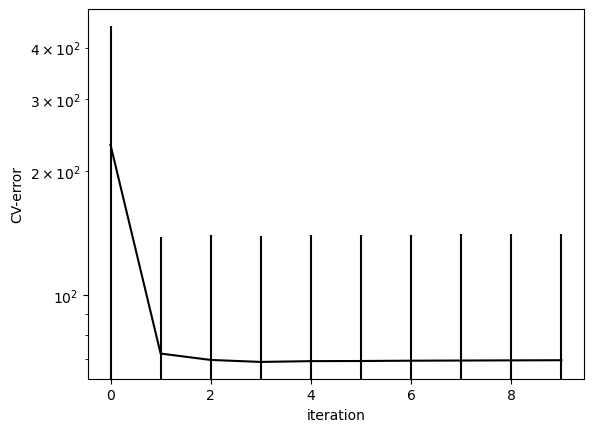

Eigenvalues:
 PC1    126.964169
PC2    103.230842
PC3     72.115732
dtype: float64
Proportion of variance explained:
 PC1    0.504106
PC2    0.333257
PC3    0.162637
dtype: float64


In [10]:
joint_dm = pd.DataFrame(dist_jnt.data, index=dist_jnt.ids, columns=dist_jnt.ids)

joint_dm.to_csv('joint_dm.tsv', sep = '\t')

#plot CV error
plt.errorbar(x=joint_rpca_obj['joint'][2]['iteration'], 
             y=joint_rpca_obj['joint'][2]['mean_CV'], 
             yerr=joint_rpca_obj['joint'][2]['std_CV'],
             c='black')
plt.ylabel('CV-error', color='black')
plt.xlabel('iteration', color='black')
plt.yscale('log')
plt.show()

#check eigenvalues and proportion of variance explained
print('Eigenvalues:\n', joint_rpca_obj['joint'][0].eigvals)
print('Proportion of variance explained:\n', joint_rpca_obj['joint'][0].proportion_explained)

In [11]:
#permanova
distances = joint_rpca_obj['joint'][1]
distances.ids = list(map(str, distances.ids))
md['Diagonsis'] = md['Diagonsis'].astype(str)

perm_res = permanova(distances, md.loc(axis=0)[distances.ids]['Diagonsis'])
perm_res

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     507
number of groups                  3
test statistic             1.841278
p-value                       0.104
number of permutations          999
Name: PERMANOVA results, dtype: object

In [12]:
md = md.rename(columns={'Diagonsis': 'Diagnosis'})

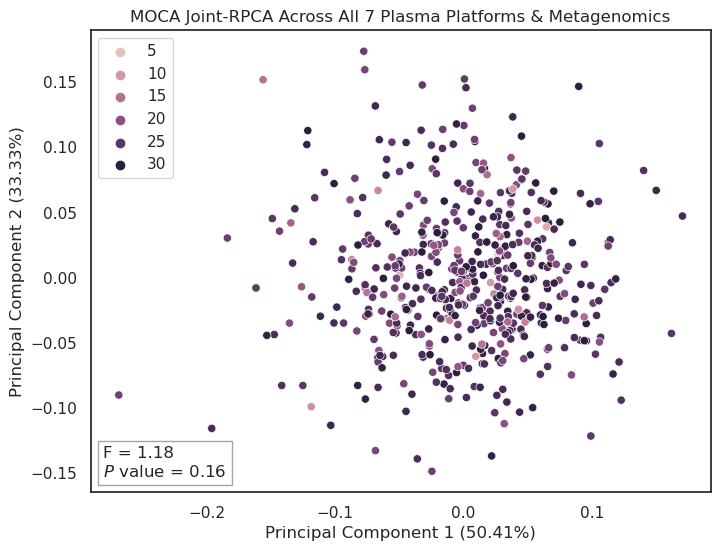

In [13]:
# Extract the sample coordinates and feature loadings as DataFrames
samples_df = pd.DataFrame(ord_jnt.samples)
features_df = pd.DataFrame(ord_jnt.features)

pc_df = samples_df

pc_df['MOCA'] = md['MOCA']

explained_variance_ratio = ord_jnt.proportion_explained*100

# Get top 10 features for PC1
top10_features_pc1 = features_df['PC1'].abs().sort_values(ascending=False).head(5).index
top10_features_pc2 = features_df['PC2'].abs().sort_values(ascending=False).head(5).index

# Combine top features
top_features = set(top10_features_pc1).union(set(top10_features_pc2))

features_df = features_df.loc[list(top_features)]

from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from adjustText import adjust_text

def plot_biplot(group):
    # Set the Seaborn style to white to remove the gray grid background
    sns.set(style="white")

    # Assuming pca is your PCA object
    explained_variance_ratio = ord_jnt.proportion_explained * 100

    # Set background to white and the same color scheme as the second plot
    plt.figure(figsize=(8, 6))

    # Plot the principal components colored by groups
    sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue=pc_df[group])

    # Label axes and add title
    plt.xlabel(f'Principal Component 1 ({round(explained_variance_ratio[0], 2)}%)')
    plt.ylabel(f'Principal Component 2 ({round(explained_variance_ratio[1], 2)}%)')
    plt.title(f'{group} Joint-RPCA Across All 7 Plasma Platforms & Metagenomics')
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # Filter out unwanted label(s)
    filtered = [(h, l) for h, l in zip(handles, labels) if l != "nan"]

    # Apply filtered legend
    ax.legend(*zip(*filtered))

    # Calculate PERMANOVA and get results
    permanova_result = permanova(distances, md.loc(axis=0)[distances.ids][group])
    test = permanova_result['test statistic']
    p = permanova_result['p-value']

    # Format p-value for display
    p_value_text = f"< .001" if p < 0.001 else f"= {p:.3f}".lstrip('0') if p < 0.01 else f"= {p:.2f}".lstrip('0')


    #Add PERMANOVA results box to the right of the plot
    plt.text(.02, .1, f"F = {test:.2f}\n$\mathit{{P}}$ value {p_value_text}", 
             fontsize=12, va='top', ha='left', transform=plt.gca().transAxes, bbox = dict(facecolor='white', alpha=0.7, edgecolor='gray'))

    # # Annotate top features with arrows and adjust text positions
    # texts = []
    # for feature in top_features:
    #     plt.arrow(0, 0, features_df.loc[feature, 'PC1'], features_df.loc[feature, 'PC2'],
    #               color='black', alpha=0.5, head_width=0.01, head_length=0.01)
    #     texts.append(
    #         plt.text(features_df.loc[feature, 'PC1'] * 1.2, features_df.loc[feature, 'PC2'] * 1.2,
    #                  feature, color='black', ha='center', va='center', fontsize=12)
    #     )

    # # Adjust text positions to avoid overlap
    # adjust_text(texts, arrowprops=dict(arrowstyle='->', color='white', alpha=0.5))

    # Save and show the plot
    plt.savefig(f'{group}_joint_rpca_all_platforms.png')
    plt.show()


plot_biplot('MOCA')

In [14]:
sig = pd.read_csv('../output_files/sig_metab_metag_results.csv', index_col=0)

In [15]:
sig['OGU'] = [taxonomy.split(';')[-1].strip() for taxonomy in sig['microbe_w_tax']]

In [16]:
fts_sig = {}

for ft in fts_scaled.keys():
    if ft != 'Metagenomics':
        fts_sig[ft] = fts_scaled[ft][fts_scaled[ft].columns[fts_scaled[ft].columns.isin(sig['metabolite'])]]

In [17]:
#transform tables in biom format
ft_biom = {}

for ft in fts:
    ft_biom[ft] = biom.Table(fts_sig[ft].values.T, 
                               sample_ids=fts_sig[ft].index, 
                               observation_ids=fts_sig[ft].columns)

In [18]:
ft_biom

{'Nightingale': 2 x 507 <class 'biom.table.Table'> with 1014 nonzero entries (100% dense),
 'Baker': 0 x 507 <class 'biom.table.Table'> with 0 nonzero entries (0% dense),
 'Metabolon': 23 x 507 <class 'biom.table.Table'> with 11661 nonzero entries (100% dense),
 'Wishart': 0 x 507 <class 'biom.table.Table'> with 0 nonzero entries (0% dense),
 'Fiehn': 0 x 507 <class 'biom.table.Table'> with 0 nonzero entries (0% dense),
 'UCSD': 5 x 507 <class 'biom.table.Table'> with 2535 nonzero entries (100% dense),
 'Tuulia': 0 x 507 <class 'biom.table.Table'> with 0 nonzero entries (0% dense)}

In [19]:
# ONLY RUN ON FIRST ITERATION
ord_jnt, dist_jnt, cv_jnt = joint_rpca([ft_biom['Metabolon'],ft_biom['UCSD']],
                                       n_test_samples=int(len(md.index) * 0.2), n_components=2,
                                      max_iterations=10, rclr_transform_tables=False)
joint_rpca_obj = {'joint': (ord_jnt, dist_jnt, cv_jnt)}

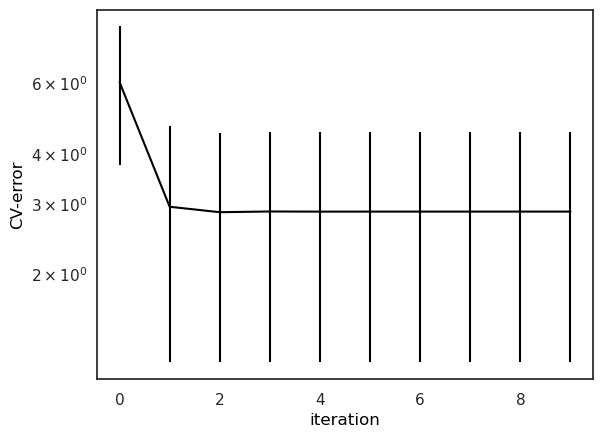

Eigenvalues:
 PC1    24.103389
PC2    16.353765
dtype: float64
Proportion of variance explained:
 PC1    0.684772
PC2    0.315228
dtype: float64


In [20]:
joint_dm = pd.DataFrame(dist_jnt.data, index=dist_jnt.ids, columns=dist_jnt.ids)

joint_dm.to_csv('joint_dm.tsv', sep = '\t')

#plot CV error
plt.errorbar(x=joint_rpca_obj['joint'][2]['iteration'], 
             y=joint_rpca_obj['joint'][2]['mean_CV'], 
             yerr=joint_rpca_obj['joint'][2]['std_CV'],
             c='black')
plt.ylabel('CV-error', color='black')
plt.xlabel('iteration', color='black')
plt.yscale('log')
plt.show()

#check eigenvalues and proportion of variance explained
print('Eigenvalues:\n', joint_rpca_obj['joint'][0].eigvals)
print('Proportion of variance explained:\n', joint_rpca_obj['joint'][0].proportion_explained)

In [21]:
#permanova
distances = joint_rpca_obj['joint'][1]
distances.ids = list(map(str, distances.ids))
md['Diagnosis'] = md['Diagnosis'].astype(str)

perm_res = permanova(distances, md.loc(axis=0)[distances.ids]['Diagnosis'])
perm_res

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     507
number of groups                  3
test statistic             4.422612
p-value                       0.007
number of permutations          999
Name: PERMANOVA results, dtype: object

In [22]:
# Extract the sample coordinates and feature loadings as DataFrames
samples_df = pd.DataFrame(ord_jnt.samples)
features_df = pd.DataFrame(ord_jnt.features)

pc_df = samples_df


In [23]:
pc_df

,PC1,PC2
15448.0042291753,0.025927,-0.038381
15448.0042311720,0.007982,0.074634
15448.0042071802,0.006534,-0.025432
15448.42360442,-0.014007,-0.042697
15448.42620855,-0.045711,-0.000951
...,...,...
15448.42225159,-0.127463,0.042817
15448.0042204369,-0.145139,-0.032411
15448.42319756,-0.170937,-0.052500
15448.42467202,-0.211662,-0.089368


In [24]:
pc_df.to_csv('../output_files/sig_metabolites_joint_rpca.csv')

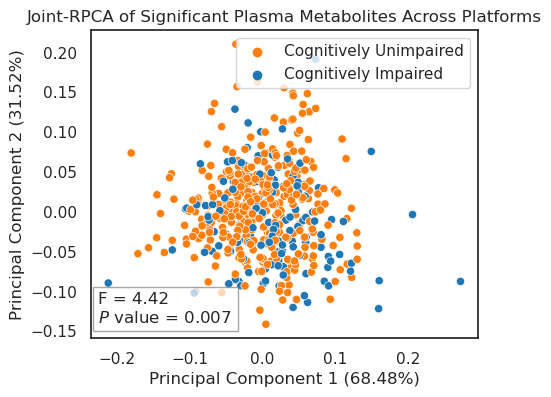

In [32]:
palette = {'Cognitively Unimpaired': '#ff7f0e', 'Cognitively Impaired': '#1f77b4'}

pc_df['Diagnosis'] = md['Diagnosis']
pc_df = pc_df.dropna()
pc_df = pc_df[pc_df['Diagnosis'] != 'nan']
explained_variance_ratio = ord_jnt.proportion_explained*100

# Get top 10 features for PC1
top10_features_pc1 = features_df['PC1'].abs().sort_values(ascending=False).head(5).index
top10_features_pc2 = features_df['PC2'].abs().sort_values(ascending=False).head(5).index

# Combine top features
top_features = set(top10_features_pc1).union(set(top10_features_pc2))

features_df = features_df.loc[list(top_features)]

from skbio.stats.distance import permanova
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from adjustText import adjust_text

def plot_biplot(group):
    # Set the Seaborn style to white to remove the gray grid background
    sns.set(style="white")

    # Assuming pca is your PCA object
    explained_variance_ratio = ord_jnt.proportion_explained * 100

    # Set background to white and the same color scheme as the second plot
    plt.figure(figsize=(5, 4))

    # Plot the principal components colored by groups
    sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue=pc_df[group], palette=palette)

    # Label axes and add title
    plt.xlabel(f'Principal Component 1 ({round(explained_variance_ratio[0], 2)}%)')
    plt.ylabel(f'Principal Component 2 ({round(explained_variance_ratio[1], 2)}%)')
    plt.title(f'Joint-RPCA of Significant Plasma Metabolites Across Platforms')
    ax = plt.gca()
    handles, labels = ax.get_legend_handles_labels()

    # # Filter out unwanted label(s)
    # filtered = [(h, l) for h, l in zip(handles, labels) if l != "nan"]

    # Apply filtered legend
    ax.legend(loc='upper right')

    # Calculate PERMANOVA and get results
    permanova_result = permanova(distances, md.loc(axis=0)[distances.ids][group])
    test = permanova_result['test statistic']
    p = permanova_result['p-value']

    # Format p-value for display
    p_value_text = f"< .001" if p < 0.001 else f"= {p:.3f}".lstrip('0') if p < 0.01 else f"= {p:.2f}".lstrip('0')


    #Add PERMANOVA results box to the right of the plot
    plt.text(.02, .15, f"F = {test:.2f}\n$\mathit{{P}}$ value {p_value_text}", 
             fontsize=12, va='top', ha='left', transform=plt.gca().transAxes, bbox = dict(facecolor='white', alpha=0.7, edgecolor='gray'))

    # # Annotate top features with arrows and adjust text positions
    # texts = []
    # for feature in top_features:
    #     plt.arrow(0, 0, features_df.loc[feature, 'PC1'], features_df.loc[feature, 'PC2'],
    #               color='black', alpha=0.5, head_width=0.01, head_length=0.01)
    #     texts.append(
    #         plt.text(features_df.loc[feature, 'PC1'] * 1.2, features_df.loc[feature, 'PC2'] * 1.2,
    #                  feature, color='black', ha='center', va='center', fontsize=12)
    #     )

    # # Adjust text positions to avoid overlap
    # adjust_text(texts, arrowprops=dict(arrowstyle='->', color='white', alpha=0.5))

    # Save and show the plot
    plt.savefig(f'{group}_joint_rpca_sig_platforms.png', bbox_inches='tight')
    plt.show()


plot_biplot('Diagnosis')

In [33]:
dfs = {}

for name, biom in ft_biom.items():
    dfs[name] = biom.to_dataframe(dense=True)
    
for name in dfs:
    dfs[name].index = [f"{name}_{f}" for f in dfs[name].index]
    
common_samples = set.intersection(
    *[set(df.columns) for df in dfs.values()]
)

print("Number of shared samples:", len(common_samples))

dfs_sub = [df[sorted(common_samples)] for df in dfs.values()]

merged_df = pd.concat(dfs_sub, axis=0)

from biom import Table

merged_biom = Table(
    merged_df.values,
    merged_df.index.tolist(),
    merged_df.columns.tolist()
)

Number of shared samples: 507


In [34]:
merged_df.to_csv('sig_metab_metag_table.csv')

In [35]:
with open("../data/micov_filtered_feature-table_matched_sig_features.biom", "w") as f:
    f.write(merged_biom.to_json("Generated by script"))

In [36]:
annot_ord = ord_jnt.features.copy()

In [37]:
annot_ordtax = pd.read_csv('/home/lakhatib/wol_tree/taxonomy.tsv', sep = '\t', index_col=0)

annot_ordtax['species'] = [taxonomy.split(';')[-1].strip() for taxonomy in annot_ordtax['Taxon']]

id_to_species = annot_ordtax['species'].to_dict()

# Rename index using the mapping
annot_ord = annot_ord.rename(index=id_to_species)

In [ ]:
platform_df = pd.read_excel('/home/lakhatib/ADRC_plasma/data/Variables and platforms.xlsx')

FileNotFoundError: [Errno 2] No such file or directory: '/home/lakhatib/ADRC_plasma/data/Variables and platforms.xlsx'

In [ ]:
# Create a dictionary mapping from Variable to Platform
platform_map = dict(zip(platform_df['Variable'], platform_df['Platform']))

In [ ]:
platform_df['Platform'].value_counts()

In [ ]:
platform_df['Platform'] = platform_df['Platform'].rename({'UCSD Known': 'UCSD'})

In [ ]:
import matplotlib.pyplot as plt

# Sort the features by their contribution to PC1
top_pc1_contributions = annot_ord['PC1'].sort_values(ascending=False).head(25)
bottom_pc1_contributions = annot_ord['PC1'].sort_values(ascending=True).head(25)

pc1_contributions = pd.concat([top_pc1_contributions, bottom_pc1_contributions])
pc1_contributions = pc1_contributions.sort_values()
# Separate microbial and inflammatory features for color coding
microbial_features = pc1_contributions[pc1_contributions.index.str.startswith('g_') | pc1_contributions.index.str.startswith('s_')]

# Define custom color palette for platforms
platform_colors = {
    'Nightingale': 'pink',
    'Metabolon': 'lightgreen',
    'Wishart Biocrates': 'yellow'
}

# Fallback color if platform is missing
default_metabolite_color = 'black'

colors = []
for feature in pc1_contributions.index:
    if feature.startswith('s_') or feature.startswith('c_'):
        colors.append('turquoise')  # Microbial feature
    else:
        platform = platform_map.get(feature, 'Unknown')
        colors.append(platform_colors.get(platform, default_metabolite_color))
        
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
pc1_contributions.plot(kind='barh', color=colors)

plt.title('Features Contributing to PC1')
plt.xlabel('Contribution to PC1')
plt.ylabel('Features')

# Create legend handles
legend_handles = [mpatches.Patch(color='turquoise', label='Metagenomics')]
for platform, color in platform_colors.items():
    legend_handles.append(mpatches.Patch(color=color, label=platform))

plt.legend(handles=legend_handles, title='Feature Type / Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/home/lakhatib/ADRC_plasma/Joint-RPCA/metag_metab_jointrpca_features_PC1.png')
plt.show()

In [238]:
fts['Metagenomics']

,G000006865,G000006925,G000007325,G000007465,G000007525,G000007785,G000008345,G000008865,G000008925,G000009925,...,G902363685,G902363725,G902363825,G902364485,G902373415,G902377395,G902385285,G902387315,G902406265,G902765685
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
15448.0005635586,-1.805133,-1.805133,NaN,NaN,NaN,-2.983788,NaN,-1.536869,NaN,3.198814,...,2.247321,-0.275737,2.023509,3.138157,-2.067497,-1.037877,3.187391,1.877961,-0.107402,NaN
15448.0005700235,-1.693048,1.146031,-3.995633,-2.386195,-0.440285,-2.049723,-2.609338,1.287571,NaN,1.529820,...,3.156636,0.667806,2.194683,1.346702,-3.995633,-1.223044,2.065824,4.013066,-3.302485,NaN
15448.0005704913,-3.244923,2.194243,NaN,NaN,-1.230020,-3.938070,NaN,2.367293,NaN,3.143219,...,3.003604,-0.236768,2.019062,2.583288,-2.685307,-0.488082,2.707021,1.500010,-1.740845,-4.631217
15448.0005704938,NaN,3.179915,-4.281151,NaN,NaN,-4.281151,NaN,3.350766,NaN,3.938983,...,3.302097,-0.519951,1.839146,2.399704,-2.671713,-1.796244,4.032946,1.360756,-1.716202,-2.894857
15448.0005707913,-2.309096,-3.407708,NaN,NaN,1.719227,NaN,NaN,-4.100855,NaN,3.083015,...,2.578744,0.543535,2.531146,2.032543,-1.392805,-2.154945,3.579320,1.140892,-3.002243,-4.100855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.42872270,-1.704090,-0.224799,NaN,-3.584403,-3.989868,-3.216678,-2.562751,-0.157610,-4.683015,4.880304,...,2.736166,1.981394,3.294267,2.770547,-1.910426,-0.744675,3.676744,1.677136,-1.638492,NaN
15448.42920267,-3.085527,NaN,NaN,NaN,NaN,-2.797845,NaN,NaN,-4.589605,3.897954,...,2.698640,0.546194,3.510253,2.823159,-1.188407,-0.306018,3.736065,2.286144,-0.213848,-5.282752
15448.42926698,NaN,1.826035,NaN,NaN,3.413966,-0.925501,NaN,1.983220,NaN,1.377084,...,0.540836,NaN,-0.637819,-0.637819,NaN,NaN,1.153941,-0.637819,NaN,NaN


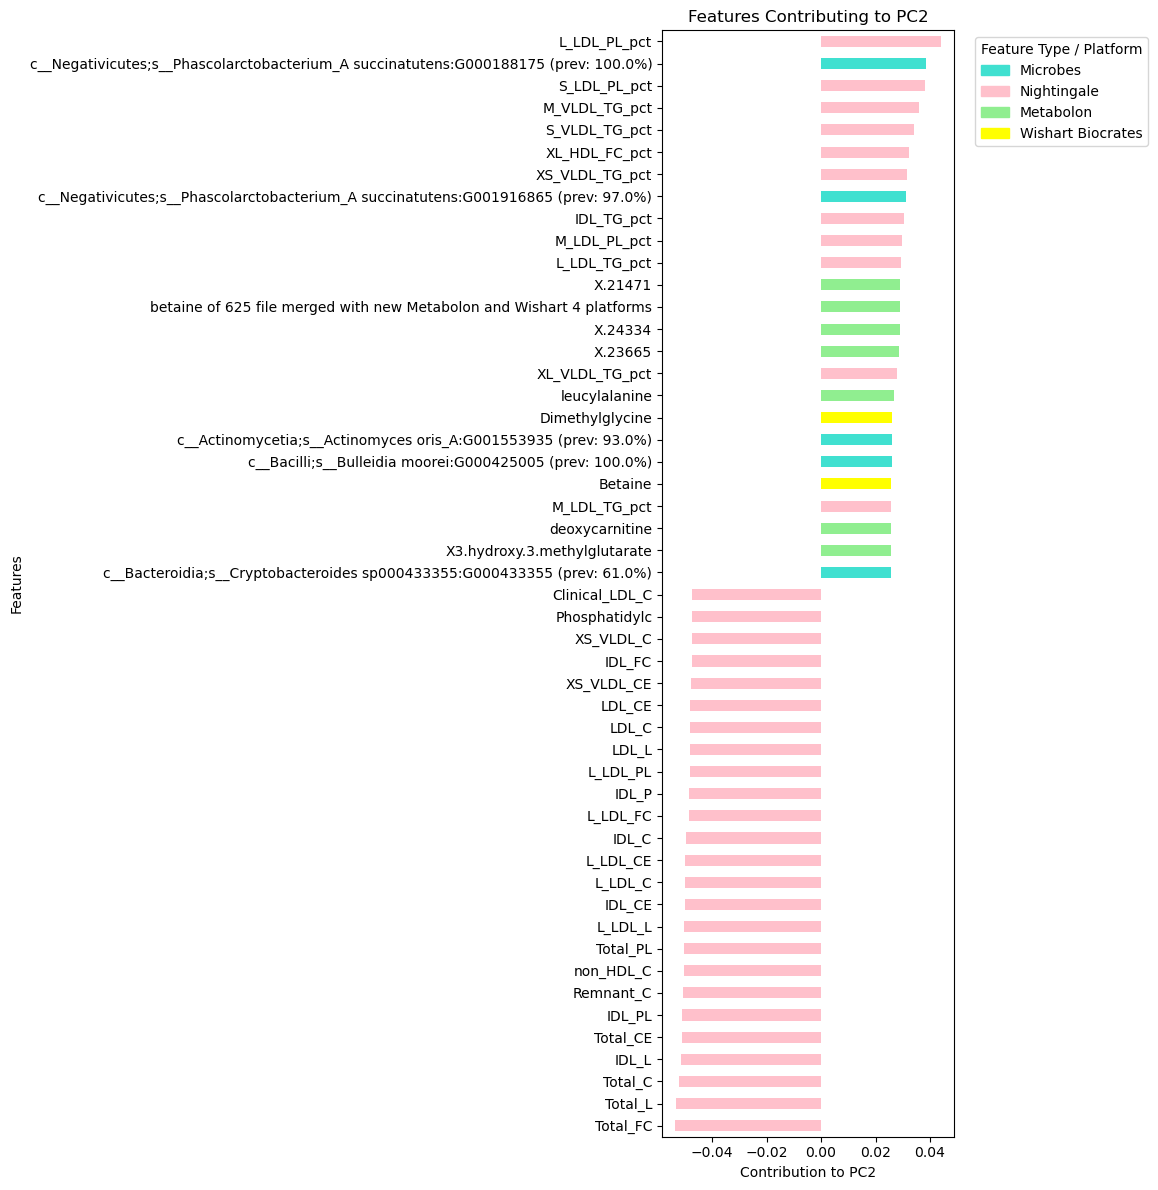

In [239]:
import matplotlib.pyplot as plt

# Sort the features by their contribution to PC1
top_pc2_contributions = annot_ord['PC2'].sort_values(ascending=False).head(25)
bottom_pc2_contributions = annot_ord['PC2'].sort_values(ascending=True).head(25)

pc2_contributions = pd.concat([top_pc2_contributions, bottom_pc2_contributions])
pc2_contributions = pc2_contributions.sort_values()
# Separate microbial and inflammatory features for color coding
microbial_features = pc2_contributions[pc2_contributions.index.str.startswith('s_') | pc2_contributions.index.str.startswith('G9')]

# Fallback color if platform is missing
default_metabolite_color = 'black'

colors = []
for feature in pc2_contributions.index:
    if feature.startswith('s_') or feature.startswith('c_'):
        colors.append('turquoise')  # Microbial feature
    else:
        platform = platform_map.get(feature, 'Unknown')
        colors.append(platform_colors.get(platform, default_metabolite_color))
        
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 12))
pc2_contributions.plot(kind='barh', color=colors)

plt.title('Features Contributing to PC2')
plt.xlabel('Contribution to PC2')
plt.ylabel('Features')

# Create legend handles
legend_handles = [mpatches.Patch(color='turquoise', label='Microbes')]
for platform, color in platform_colors.items():
    legend_handles.append(mpatches.Patch(color=color, label=platform))

plt.legend(handles=legend_handles, title='Feature Type / Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/home/lakhatib/ADRC_plasma/Joint-RPCA/metag_metab_jointrpca_features_PC2.png')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Sort the features by their contribution to PC1
top_pc2_contributions = annot_ord['PC2'].sort_values(ascending=False).head(25)
bottom_pc2_contributions = annot_ord['PC2'].sort_values(ascending=True).head(25)

pc2_contributions = pd.concat([top_pc2_contributions, bottom_pc2_contributions])
pc2_contributions = pc2_contributions.sort_values()
# Separate microbial and inflammatory features for color coding
microbial_features = pc2_contributions[pc2_contributions.index.str.startswith('s_') | pc2_contributions.index.str.startswith('G9')]

# Fallback color if platform is missing
default_metabolite_color = 'black'

colors = []
for feature in pc2_contributions.index:
    if feature.startswith('s_') or feature.startswith('c_'):
        colors.append('turquoise')  # Microbial feature
    else:
        platform = platform_map.get(feature, 'Unknown')
        colors.append(platform_colors.get(platform, default_metabolite_color))
        
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(12, 12))
pc2_contributions.plot(kind='barh', color=colors)

plt.title('Features Contributing to PC2')
plt.xlabel('Contribution to PC2')
plt.ylabel('Features')

# Create legend handles
legend_handles = [mpatches.Patch(color='turquoise', label='Microbes')]
for platform, color in platform_colors.items():
    legend_handles.append(mpatches.Patch(color=color, label=platform))

plt.legend(handles=legend_handles, title='Feature Type / Platform', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/home/lakhatib/ADRC_plasma/Joint-RPCA/metag_metab_jointrpca_features_PC2.png')
plt.show()

In [255]:
annot = pd.read_excel('/home/lakhatib/ADRC_plasma/data/Variables and platforms.xlsx', index_col='Variable')

In [263]:
annot = annot[~annot.index.duplicated()]

In [264]:
annot_ord = annot_ord[~annot_ord.index.duplicated()]

In [265]:
annot_ord['platform'] = annot['Platform']

In [272]:
annot_ord['platform'] = annot_ord['platform'].fillna('Metagenomics')

In [287]:
annot_ord['platform'] = annot_ord['platform'].replace({'Wishart Biocrates': 'Wishart', 'UCSD Known': 'UCSD', 'Tuulia Known': 'Tuulia',
                                       'Wishart Metals': 'Wishart', 'Wishart Water soluble vitamines': 'Wishart', 
                                       'Wishart Fat soluble vitamines': 'Wishart'})

In [288]:
annot_ord['platform'].value_counts()

platform
Metagenomics    1102
Metabolon       1059
Baker            820
Wishart          577
UCSD             403
Nightingale      242
Tuulia           122
WCMC (FIEHN)     116
Name: count, dtype: int64

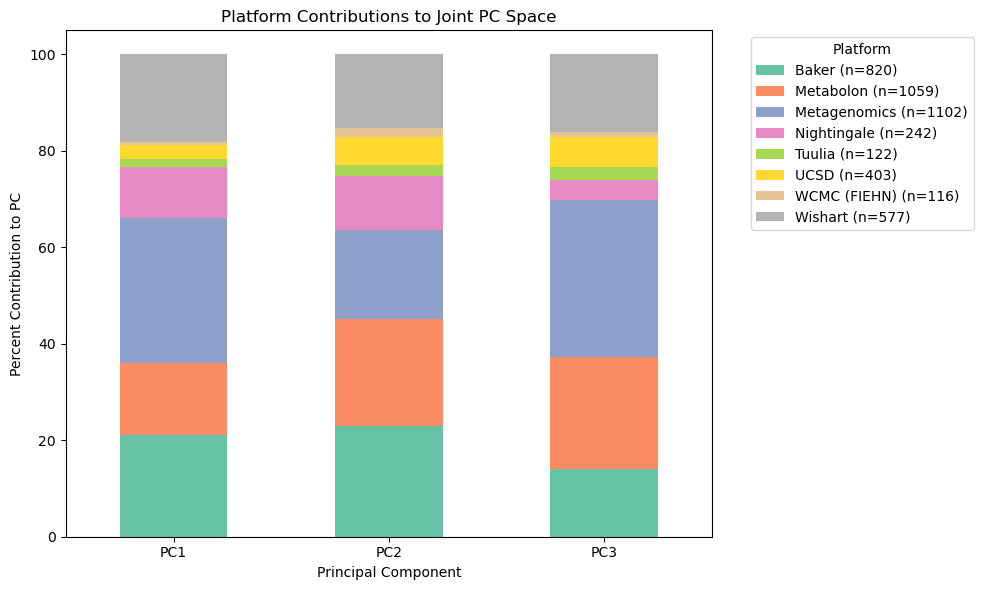

In [291]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Take absolute values of loadings
abs_loadings = annot_ord[['PC1', 'PC2', 'PC3']].abs()
abs_loadings['platform'] = annot_ord['platform']

# Step 2: Sum loadings by platform
platform_contrib = abs_loadings.groupby('platform').sum()

# Step 3: Convert to percentages
platform_contrib_percent = platform_contrib.div(platform_contrib.sum(axis=0), axis=1) * 100

# Step 4: Count features per platform
platform_counts = annot_ord['platform'].value_counts().to_dict()

# Step 5: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
plot = platform_contrib_percent.T.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)

# Step 6: Modify legend labels to include counts
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"{label} (n={platform_counts[label]})" for label in labels]
ax.legend(handles, new_labels, title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')

# Final formatting
plt.ylabel('Percent Contribution to PC')
plt.xlabel('Principal Component')
plt.title('Platform Contributions to Joint PC Space')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('platform_contrib_joint_PC_space.png')
plt.show()


In [294]:
platform_contrib_percent

,PC1,PC2,PC3
platform,,,
Baker,15.288705,14.992871,10.629595
Metabolon,8.300646,11.171018,13.555786
Metagenomics,16.205167,8.918164,18.399991
Nightingale,25.514896,24.658061,10.341825
Tuulia,8.244028,10.385396,14.456748
UCSD,4.172860,7.697783,9.551318
WCMC (FIEHN),3.630363,8.031775,5.874134
Wishart,18.643336,14.144933,17.190603


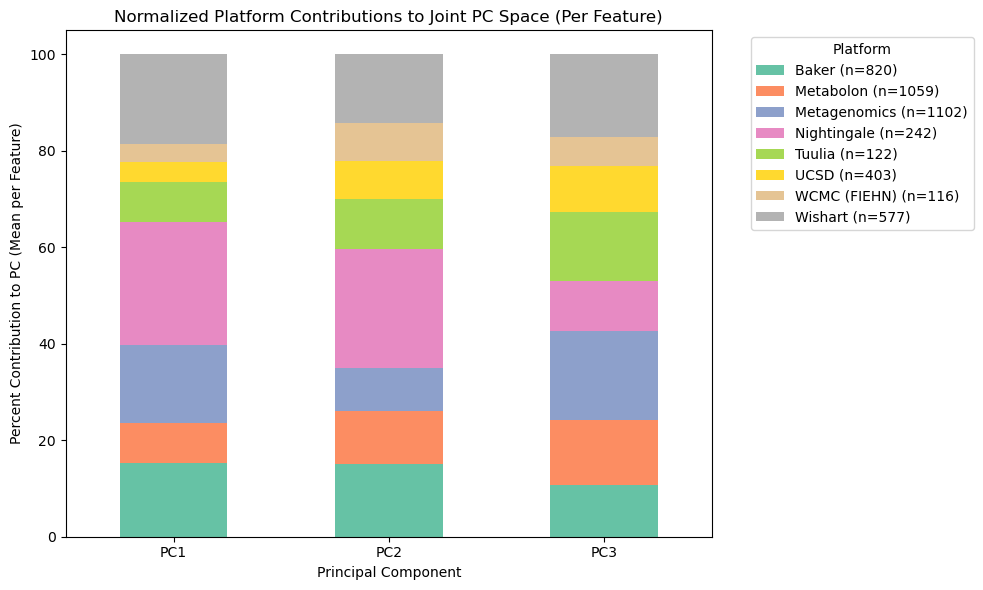

In [292]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Take absolute values of loadings
abs_loadings = annot_ord[['PC1', 'PC2', 'PC3']].abs()
abs_loadings['platform'] = annot_ord['platform']

# Step 2: Compute **mean** loadings by platform (not sum)
platform_contrib_mean = abs_loadings.groupby('platform').mean()

# Step 3: Convert to percentages for each PC
platform_contrib_percent = platform_contrib_mean.div(platform_contrib_mean.sum(axis=0), axis=1) * 100

# Step 4: Count features per platform (still used for legend)
platform_counts = annot_ord['platform'].value_counts().to_dict()

# Step 5: Plot stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
plot = platform_contrib_percent.T.plot(kind='bar', stacked=True, colormap='Set2', ax=ax)

# Step 6: Modify legend labels to include counts
handles, labels = ax.get_legend_handles_labels()
new_labels = [f"{label} (n={platform_counts[label]})" for label in labels]
ax.legend(handles, new_labels, title="Platform", bbox_to_anchor=(1.05, 1), loc='upper left')

# Final formatting
plt.ylabel('Percent Contribution to PC (Mean per Feature)')
plt.xlabel('Principal Component')
plt.title('Normalized Platform Contributions to Joint PC Space (Per Feature)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('platform_contrib_joint_PC_space_normalized.png')
plt.show()


In [275]:
# PC1 layer contribution
contrib = annot_ord.groupby('platform')['PC1'].sum()  # or mean()

# Normalize to percent
contrib_percent = 100 * contrib / contrib.sum()
print(contrib_percent)

platform
Baker                              -2453.897472
Metabolon                           -190.215900
Metagenomics                       19826.510594
Nightingale                         -432.968189
Tuulia Known                         447.595172
UCSD Known                          2492.843737
WCMC (FIEHN)                         953.640981
Wishart Biocrates                 -20678.086823
Wishart Fat soluble vitamines        -55.557338
Wishart Metals                       199.102844
Wishart Water soluble vitamines       -8.967606
Name: PC1, dtype: float64


In [240]:
#plot feature correlation as heatmap
feature_correlation = feature_correlation_table(joint_rpca_obj['joint'][0])


In [241]:
feature_correlation = feature_correlation.rename(index=id_to_species)

In [242]:
feature_correlation = feature_correlation.rename(columns=id_to_species)

In [243]:
feature_correlation_pc1 = feature_correlation[pc1_contributions.index]

In [244]:
pc1_contributions

M_LDL_FC_pct                                                               -0.047814
L_LDL_FC_pct                                                               -0.047052
M_HDL_C_pct                                                                -0.045358
M_HDL_CE_pct                                                               -0.043962
c__Clostridia;s__Massilioclostridium coli:G900095865 (prev: 100.0%)        -0.043520
XS_VLDL_CE_pct                                                             -0.043052
XS_VLDL_C_pct                                                              -0.042310
M_VLDL_CE_pct                                                              -0.041143
L_HDL_C_pct                                                                -0.040523
c__Clostridia;s__Phil1 sp001940855:G001940855 (prev: 100.0%)               -0.040425
M_VLDL_C_pct                                                               -0.040184
L_HDL_CE_pct                                                     

In [245]:
fts['Metagenomics']

,G000006865,G000006925,G000007325,G000007465,G000007525,G000007785,G000008345,G000008865,G000008925,G000009925,...,G902363685,G902363725,G902363825,G902364485,G902373415,G902377395,G902385285,G902387315,G902406265,G902765685
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
15448.0005635586,-1.805133,-1.805133,NaN,NaN,NaN,-2.983788,NaN,-1.536869,NaN,3.198814,...,2.247321,-0.275737,2.023509,3.138157,-2.067497,-1.037877,3.187391,1.877961,-0.107402,NaN
15448.0005700235,-1.693048,1.146031,-3.995633,-2.386195,-0.440285,-2.049723,-2.609338,1.287571,NaN,1.529820,...,3.156636,0.667806,2.194683,1.346702,-3.995633,-1.223044,2.065824,4.013066,-3.302485,NaN
15448.0005704913,-3.244923,2.194243,NaN,NaN,-1.230020,-3.938070,NaN,2.367293,NaN,3.143219,...,3.003604,-0.236768,2.019062,2.583288,-2.685307,-0.488082,2.707021,1.500010,-1.740845,-4.631217
15448.0005704938,NaN,3.179915,-4.281151,NaN,NaN,-4.281151,NaN,3.350766,NaN,3.938983,...,3.302097,-0.519951,1.839146,2.399704,-2.671713,-1.796244,4.032946,1.360756,-1.716202,-2.894857
15448.0005707913,-2.309096,-3.407708,NaN,NaN,1.719227,NaN,NaN,-4.100855,NaN,3.083015,...,2.578744,0.543535,2.531146,2.032543,-1.392805,-2.154945,3.579320,1.140892,-3.002243,-4.100855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.42872270,-1.704090,-0.224799,NaN,-3.584403,-3.989868,-3.216678,-2.562751,-0.157610,-4.683015,4.880304,...,2.736166,1.981394,3.294267,2.770547,-1.910426,-0.744675,3.676744,1.677136,-1.638492,NaN
15448.42920267,-3.085527,NaN,NaN,NaN,NaN,-2.797845,NaN,NaN,-4.589605,3.897954,...,2.698640,0.546194,3.510253,2.823159,-1.188407,-0.306018,3.736065,2.286144,-0.213848,-5.282752
15448.42926698,NaN,1.826035,NaN,NaN,3.413966,-0.925501,NaN,1.983220,NaN,1.377084,...,0.540836,NaN,-0.637819,-0.637819,NaN,NaN,1.153941,-0.637819,NaN,NaN


In [246]:
feature_correlation_pc1 = feature_correlation_pc1.loc[pc1_contributions.index]

In [247]:
feature_correlation_pc2 = feature_correlation[pc2_contributions.index]
feature_correlation_pc2 = feature_correlation_pc2.loc[pc2_contributions.index]

In [248]:
feature_correlation_pc1 

featureid,M_LDL_FC_pct,L_LDL_FC_pct,M_HDL_C_pct,M_HDL_CE_pct,c__Clostridia;s__Massilioclostridium coli:G900095865 (prev: 100.0%),XS_VLDL_CE_pct,XS_VLDL_C_pct,M_VLDL_CE_pct,L_HDL_C_pct,c__Clostridia;s__Phil1 sp001940855:G001940855 (prev: 100.0%),...,L_HDL_TG_pct,M_HDL_TG_pct,XL_VLDL_TG,XL_HDL_TG_pct,Total_TG,VLDL_TG,S_VLDL_TG,S_HDL_TG,S_HDL_TG_pct,TG_by_PG
M_LDL_FC_pct,1.000000,0.967380,0.990977,0.981365,0.993481,0.901742,0.893985,0.914927,0.978308,0.945764,...,-0.946957,-0.943443,-0.967020,-0.954268,-0.969438,-0.973548,-0.970906,-0.959939,-0.905613,-0.929725
L_LDL_FC_pct,0.967380,1.000000,0.985422,0.917982,0.943154,0.973487,0.971226,0.982798,0.998396,0.855325,...,-0.990478,-0.987486,-0.972134,-0.990200,-0.915478,-0.939273,-0.944368,-0.979624,-0.978553,-0.988534
M_HDL_C_pct,0.990977,0.985422,1.000000,0.971538,0.984412,0.922156,0.917432,0.937635,0.993472,0.893900,...,-0.980201,-0.978560,-0.990867,-0.985085,-0.970249,-0.982533,-0.983959,-0.988621,-0.950691,-0.967478
M_HDL_CE_pct,0.981365,0.917982,0.971538,1.000000,0.996862,0.811167,0.802374,0.832651,0.938756,0.924347,...,-0.912093,-0.911423,-0.961877,-0.924116,-0.995929,-0.990176,-0.985362,-0.945760,-0.857354,-0.884794
c__Clostridia;s__Massilioclostridium coli:G900095865 (prev: 100.0%),0.993481,0.943154,0.984412,0.996862,1.000000,0.852818,0.844490,0.871054,0.959904,0.936207,...,-0.931661,-0.929868,-0.969218,-0.941741,-0.989822,-0.988311,-0.984474,-0.956865,-0.882479,-0.908489
XS_VLDL_CE_pct,0.901742,0.973487,0.922156,0.811167,0.852818,1.000000,0.999712,0.998731,0.959533,0.795999,...,-0.949621,-0.943740,-0.895090,-0.943214,-0.801075,-0.836133,-0.844100,-0.913739,-0.957088,-0.960888
XS_VLDL_C_pct,0.893985,0.971226,0.917432,0.802374,0.844490,0.999712,1.000000,0.998498,0.956455,0.781687,...,-0.949582,-0.943951,-0.892556,-0.942597,-0.793885,-0.830523,-0.839234,-0.912294,-0.959633,-0.961981
M_VLDL_CE_pct,0.914927,0.982798,0.937635,0.832651,0.871054,0.998731,0.998498,1.000000,0.970944,0.801207,...,-0.964200,-0.959197,-0.915659,-0.958682,-0.825746,-0.859762,-0.867767,-0.932759,-0.969473,-0.973435
L_HDL_C_pct,0.978308,0.998396,0.993472,0.938756,0.959904,0.959533,0.956455,0.970944,1.000000,0.870718,...,-0.990345,-0.987802,-0.981592,-0.991780,-0.936695,-0.956755,-0.960659,-0.985875,-0.972558,-0.984813
c__Clostridia;s__Phil1 sp001940855:G001940855 (prev: 100.0%),0.945764,0.855325,0.893900,0.924347,0.936207,0.795999,0.781687,0.801207,0.870718,1.000000,...,-0.797297,-0.789054,-0.833572,-0.809121,-0.886300,-0.871938,-0.860021,-0.816851,-0.732810,-0.772191


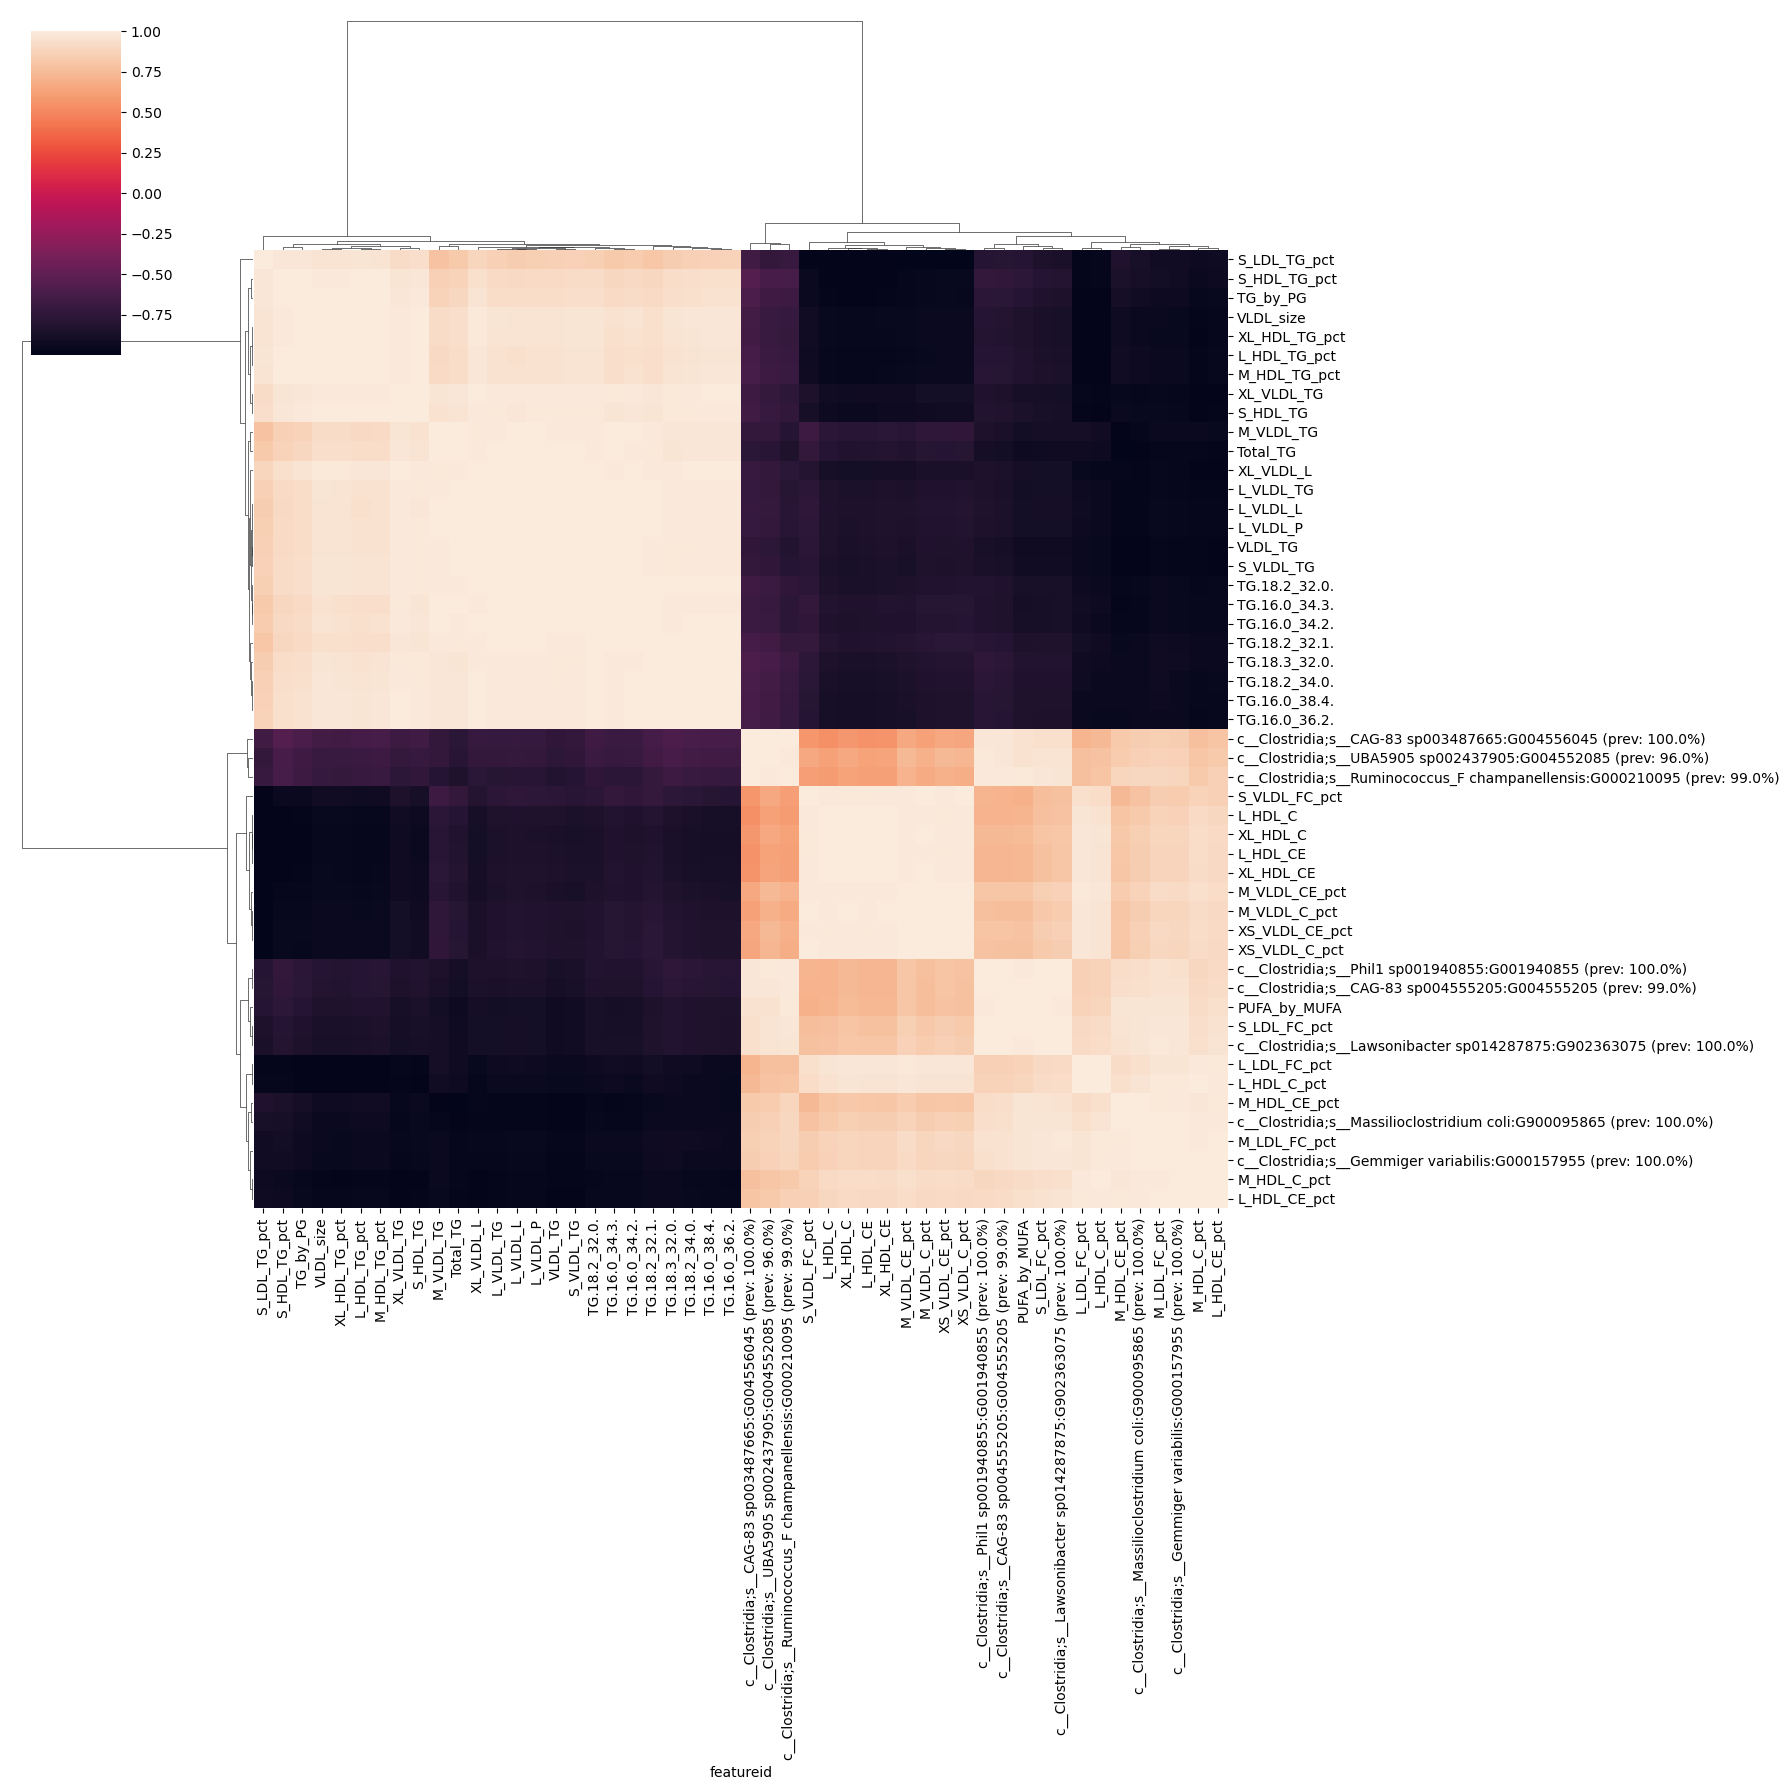

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create the clustermap with row_colors for abundance and class-based row label coloring
clustermap = sns.clustermap(
    feature_correlation_pc1,
    yticklabels=True,
    xticklabels=True,
    # row_colors=classification_colors,  # Keep the existing row_colors for abundance
    # col_colors=classification_colors,
    figsize=(18, 18)
)


# Save and show the plot
plt.savefig('/home/lakhatib/ADRC_plasma/Joint-RPCA/pc1_features_clustermap.png', bbox_inches='tight')
plt.show()


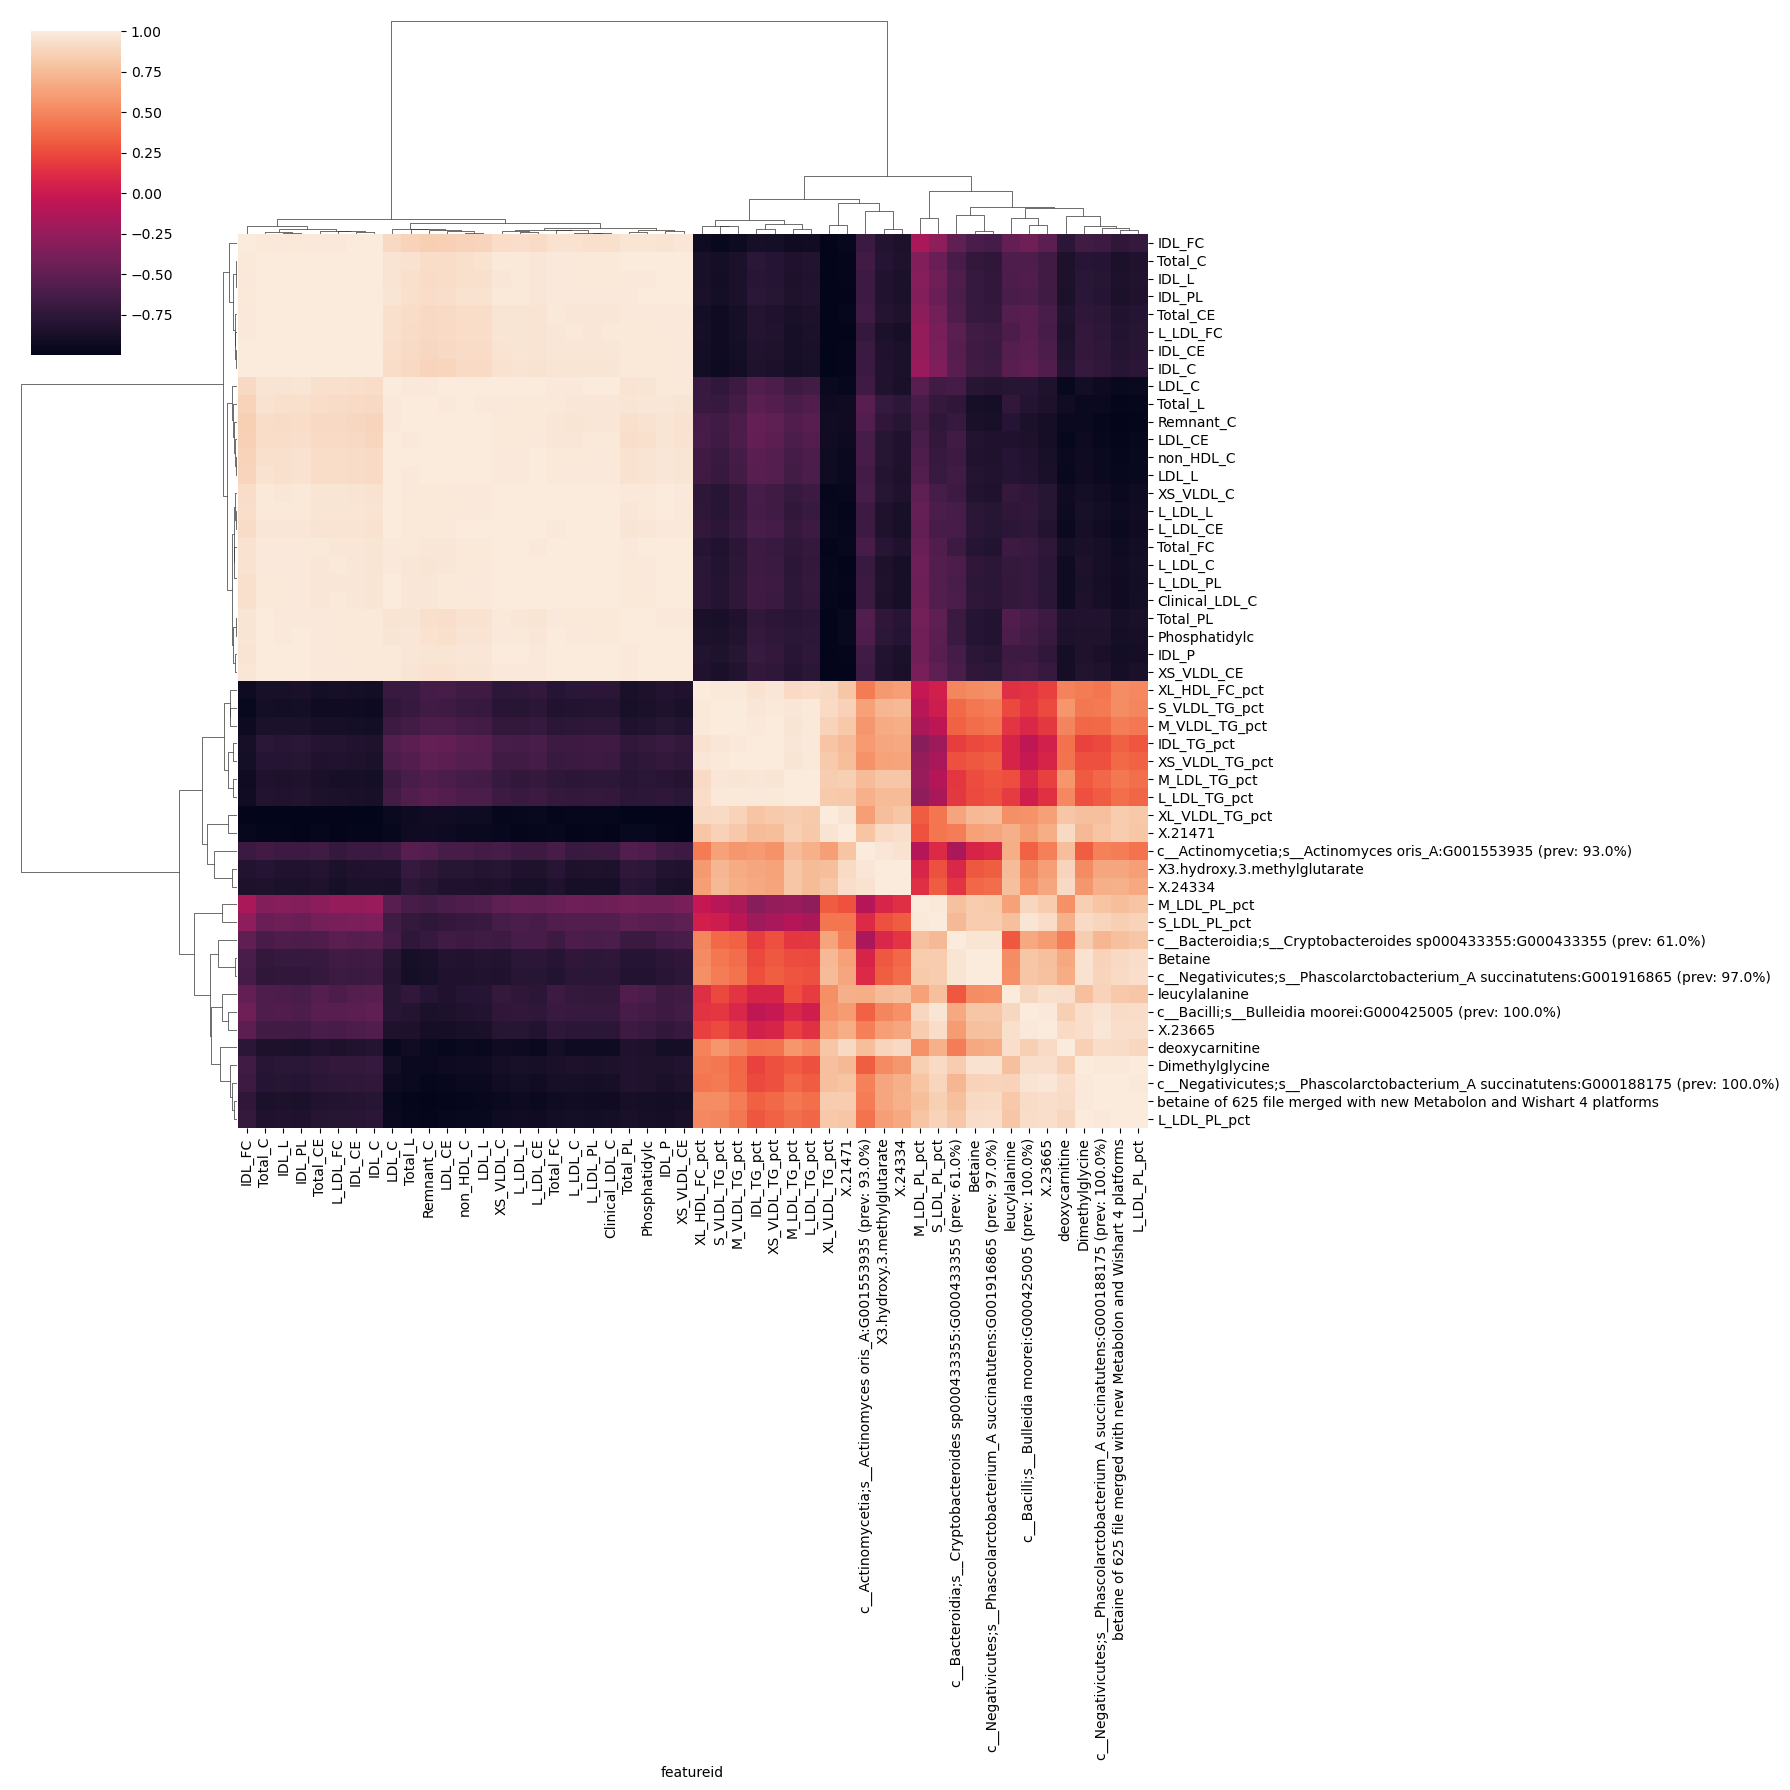

In [250]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create the clustermap with row_colors for abundance and class-based row label coloring
clustermap = sns.clustermap(
    feature_correlation_pc2,
    yticklabels=True,
    xticklabels=True,
    # row_colors=classification_colors,  # Keep the existing row_colors for abundance
    # col_colors=classification_colors,
    figsize=(18, 18)
)


# Save and show the plot
plt.savefig('/home/lakhatib/ADRC_plasma/Joint-RPCA/pc2_features_clustermap.png', bbox_inches='tight')
plt.show()